In [74]:
import pandas as pd
import matplotlib.pyplot as plt


import seaborn as sns
import random
import json

import constants
from model_utils import *

from ast import literal_eval
from pathlib import Path

import matplotlib.cm as cm

from matplotlib.colors import LinearSegmentedColormap

import numpy as np

In [75]:
#plt.style.use('ggplot')
sns.set_palette('hls', 18)
SPLIT = 'all'
model_type = constants.RectalCancerStagingData
base_dir = Path.cwd().parent

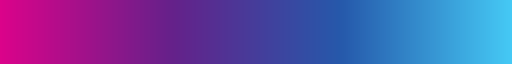

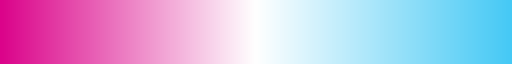

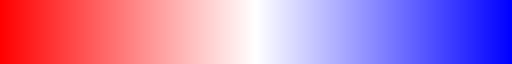

In [76]:
finomnia_palette = sns.color_palette(('#db038a',   # Pink
                                      '#66218a',   # Violet
                                      '#081c36',   # Dark Blue
                                      '#2659ab',   # blue
                                      '#45c9f5'))  # Light blue
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], finomnia_palette[1], finomnia_palette[-2], finomnia_palette[-1]])
display(finomnia_cmap)
finomnia_cmap = LinearSegmentedColormap.from_list("mio_cmap", [finomnia_palette[0], '#ffffff', finomnia_palette[-1]])
display(finomnia_cmap)
red_white_blue = LinearSegmentedColormap.from_list("red_blue", ["#ff0000", '#ffffff', "#0000ff"])
display(red_white_blue)


In [77]:
greens = sns.color_palette('Greens', 10)
blues = sns.color_palette('Blues', 10)
oranges = sns.color_palette('Oranges', 10)
reds = sns.color_palette('Reds', 10)
purples = sns.color_palette('Purples', 10)
greys = sns.color_palette('Greys', 10)

In [78]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,          # i caption in LaTeX sono spesso 9-10pt
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 150,       # per la preview; il salvataggio usa il suo
})

# Total performance

In [79]:
scores = pd.read_csv(base_dir / 'data' / 'metrics' / 'scores.csv')
scores.rename(
    columns={
        constants.OPENAI_GPT_4_1_NANO: 'GPT 4.1 Nano',
        f'{constants.OPENAI_GPT_4_1_NANO}_few-shots': 'GPT 4.1 Nano few-shots',
        f'{constants.OPENAI_GPT_4_1_NANO}_MMR': 'GPT 4.1 Nano few-shots MMR',
        constants.TUNED_GPT_4_1_NANO: 'GPT 4.1 Nano FT',
        constants.TUNED_GPT_4_1_NANO_OVERSAMPLE: 'GPT 4.1 Nano FT OS',
        constants.OPENAI_GPT_4_1_MINI: 'GPT 4.1 Mini',
        constants.OPENAI_GPT_4_1: 'GPT 4.1',
        constants.TUNED_GPT_4_1: 'GPT 4.1 FT',
        #constants.TUNED_GPT_4_1_OVERSAMPLING: 'gpt_4_1_tuned_oversampling',
        #f'few_shots_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_few_shots',
        #f'MMR_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_MMR',
        constants.OPENAI_GPT_5_4: 'GPT 5.4 reasoning',
        constants.MISTRAL_LARGE_3: 'Mistral Large 3',
        constants.CLAUDE_OPUS_4_6: 'Opus 4.6',
        #f'few_shots_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_few_shots',
        #f'MMR_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_MMR'
        constants.LLAMA_3_2_3B_TUNED: 'Llama 3.2 3B Tuned',
    },
    inplace=True
)

print(scores.split.value_counts())

train_scores = scores[scores.split=='train']
validation_scores = scores[scores.split=='validation']
test_scores = scores[scores.split=='test']

if SPLIT == 'val-test':
    scores = pd.concat([validation_scores, test_scores], ignore_index=True)
elif SPLIT == 'test':
    scores = test_scores
    
scores.set_index('id', inplace=True)

print(len(scores))

split
train         187
test           65
validation     63
Name: count, dtype: int64
315


In [80]:
scores.head()

,split,Opus 4.6,GPT 4.1 FT,GPT 4.1 Nano FT OS,GPT 4.1 Nano FT,GPT 4.1,GPT 4.1 Mini,GPT 4.1 Nano,GPT 4.1 Nano few-shots MMR,GPT 4.1 Nano few-shots,GPT 5.4 reasoning,Llama 3.2 3B Tuned,Mistral Large 3
id,,,,,,,,,,,,,
51,validation,0.971751,0.887006,0.847458,0.743879,0.887006,0.830508,0.621469,0.706215,0.706215,0.830508,0.677966,0.943503
57,validation,0.811676,0.802260,0.689266,0.632768,0.868173,0.839925,0.734463,0.677966,0.687382,0.924670,0.612053,0.905838
61,validation,0.861582,0.852166,0.852166,0.852166,0.739171,0.795669,0.781689,0.649862,0.649862,0.745763,0.659134,0.739171
66,validation,0.974105,0.981168,0.971751,0.971751,0.934557,0.924670,0.762712,0.706215,0.677966,0.915254,0.677966,0.896422
73,validation,0.993409,0.996610,0.964972,0.988701,0.993837,0.908192,0.847458,0.847458,0.847458,1.000000,0.924670,0.996610


In [81]:
compared_models = [
    'GPT 4.1 Nano',
    #'GPT 4.1 Nano few-shots',
    #'GPT 4.1 Nano few-shots MMR',
    #'GPT 4.1 Nano FT',
    #'GPT 4.1 Nano FT OS',
    #'Llama 3.2 3B Tuned',
    #'Llama 3.2 1B Tuned',
    'GPT 4.1 Mini',
    'GPT 4.1',
    #'GPT 4.1 FT',
    'GPT 5.4 reasoning',
    'Mistral Large 3',
    'Opus 4.6'
]
scores = scores[compared_models]

In [82]:
scores.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
GPT 4.1 Nano,315.0,0.70,0.10,0.42,0.62,0.71,0.77,0.96
GPT 4.1 Mini,315.0,0.85,0.09,0.55,0.79,0.86,0.92,1.01
GPT 4.1,315.0,0.87,0.09,0.58,0.82,0.89,0.94,1.00
GPT 5.4 reasoning,315.0,0.89,0.08,0.58,0.84,0.90,0.94,1.00
Mistral Large 3,315.0,0.87,0.09,0.48,0.80,0.88,0.93,1.00
Opus 4.6,315.0,0.89,0.09,0.54,0.85,0.91,0.95,1.00


In [83]:
colori = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#F0E442", "#56B4E9"]
sns.set_palette(colori)

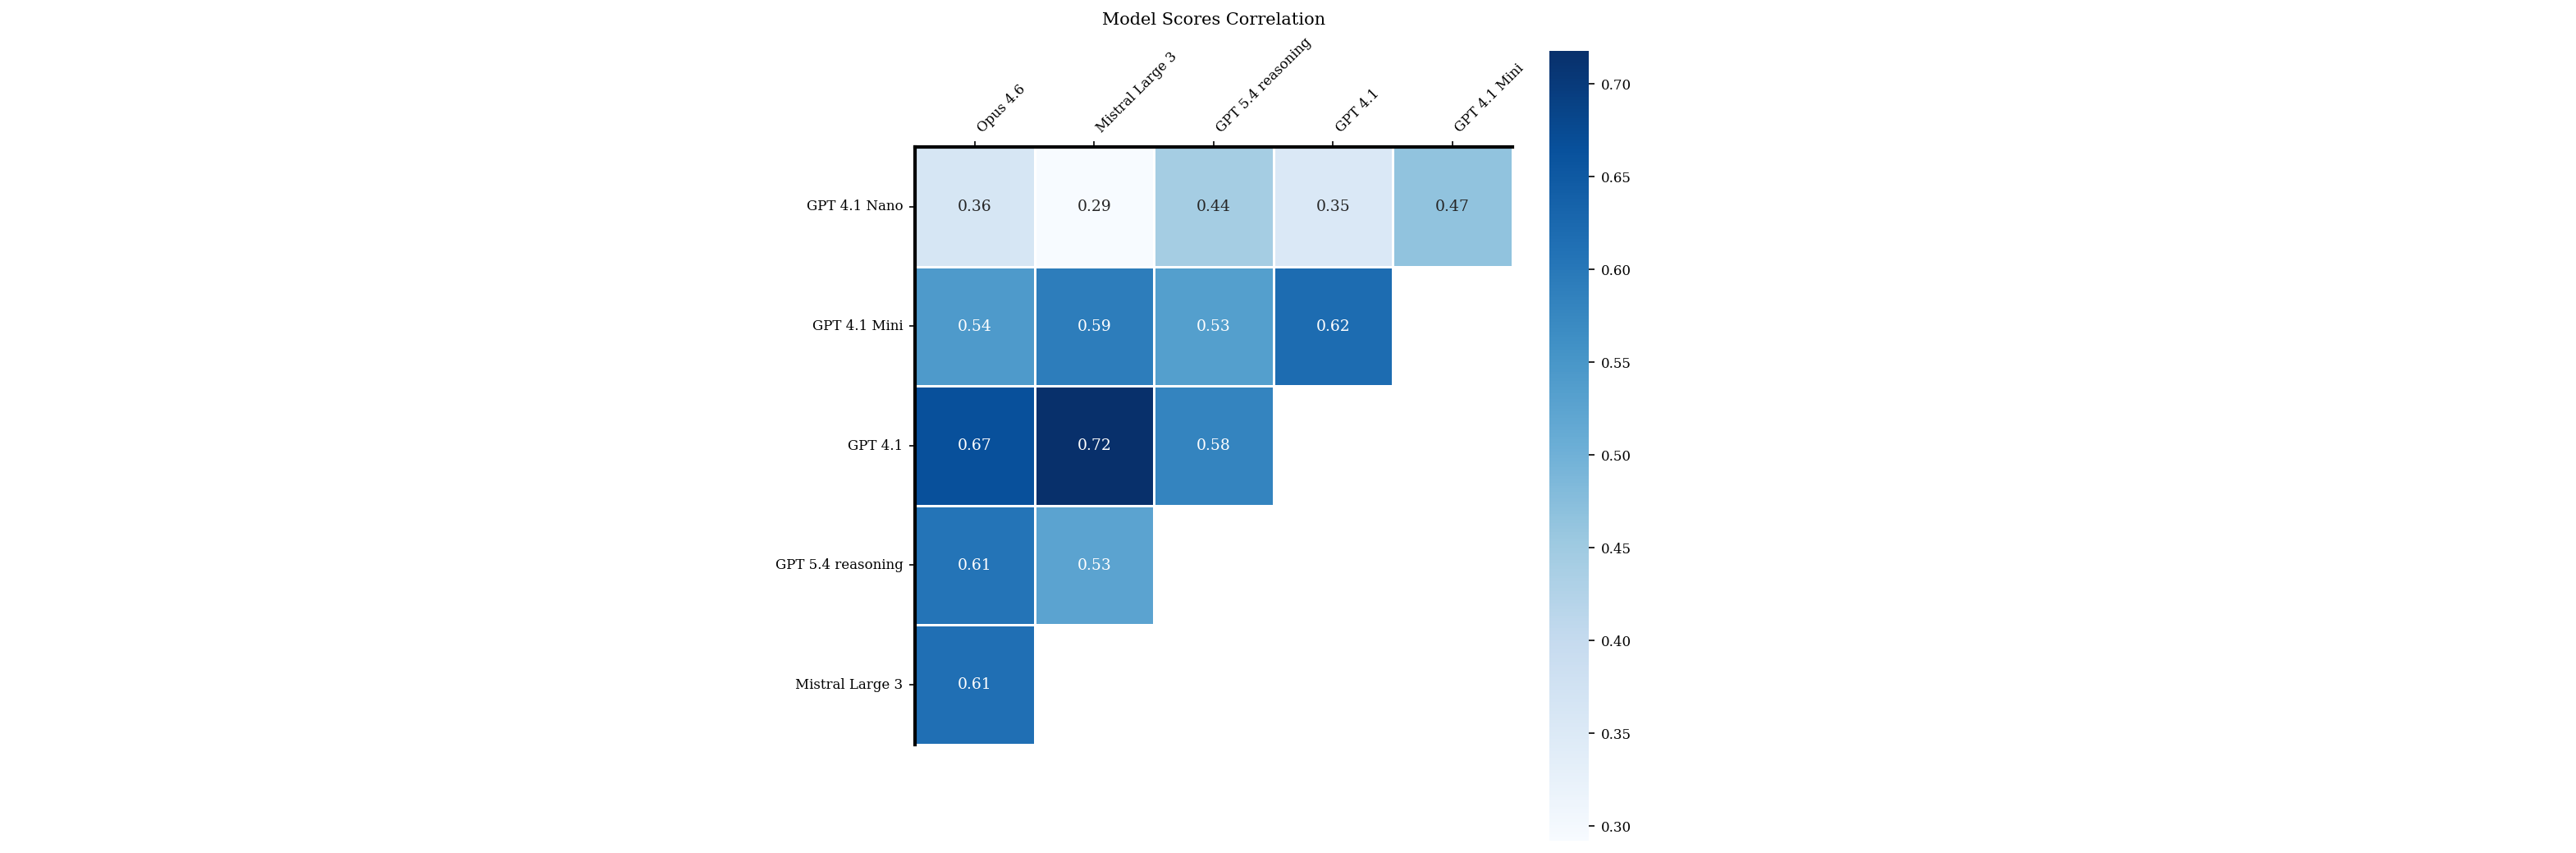

In [84]:
corr = scores.corr()
corr = corr[corr.columns[::-1]]
mask = np.tril(np.ones_like(corr, dtype=bool), k=0)
mask = mask[:, ::-1]

corr = corr.iloc[:-1, :-1]
mask = mask[:-1, :-1]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
# Whiten axes[0] and axes[2]
for i in [0, 2]:
    ax_i = axes[i]
    ax_i.set_facecolor("white")
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    for spine in ax_i.spines.values():
        spine.set_visible(False)
    
ax = axes[1]
sns.heatmap(corr, mask=mask, cmap='Blues', annot=True,
                 fmt=".2f", square=True, linewidths=0.5, ax=ax)
                 #vmin=-1, vmax=1, center=0, ax=ax)
ax.set_facecolor("white")
ax.set_title("Model Scores Correlation")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

ax.spines['top'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')

plt.tight_layout()
plt.show()

In [85]:
corr

,Opus 4.6,Mistral Large 3,GPT 5.4 reasoning,GPT 4.1,GPT 4.1 Mini
GPT 4.1 Nano,0.362682,0.292149,0.442416,0.354329,0.465274
GPT 4.1 Mini,0.543045,0.591859,0.534040,0.619436,1.000000
GPT 4.1,0.665794,0.718052,0.580199,1.000000,0.619436
GPT 5.4 reasoning,0.605725,0.525981,1.000000,0.580199,0.534040
Mistral Large 3,0.614525,1.000000,0.525981,0.718052,0.591859


In [86]:
couples = []
for i in range(len(corr)):
    for j in range(len(corr) - i):
        couples.append((i, j, corr.index[i], corr.columns[j]))

In [87]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [88]:
couples

[(0, 0, 'GPT 4.1 Nano', 'Opus 4.6'),
 (0, 1, 'GPT 4.1 Nano', 'Mistral Large 3'),
 (0, 2, 'GPT 4.1 Nano', 'GPT 5.4 reasoning'),
 (0, 3, 'GPT 4.1 Nano', 'GPT 4.1'),
 (0, 4, 'GPT 4.1 Nano', 'GPT 4.1 Mini'),
 (1, 0, 'GPT 4.1 Mini', 'Opus 4.6'),
 (1, 1, 'GPT 4.1 Mini', 'Mistral Large 3'),
 (1, 2, 'GPT 4.1 Mini', 'GPT 5.4 reasoning'),
 (1, 3, 'GPT 4.1 Mini', 'GPT 4.1'),
 (2, 0, 'GPT 4.1', 'Opus 4.6'),
 (2, 1, 'GPT 4.1', 'Mistral Large 3'),
 (2, 2, 'GPT 4.1', 'GPT 5.4 reasoning'),
 (3, 0, 'GPT 5.4 reasoning', 'Opus 4.6'),
 (3, 1, 'GPT 5.4 reasoning', 'Mistral Large 3'),
 (4, 0, 'Mistral Large 3', 'Opus 4.6')]

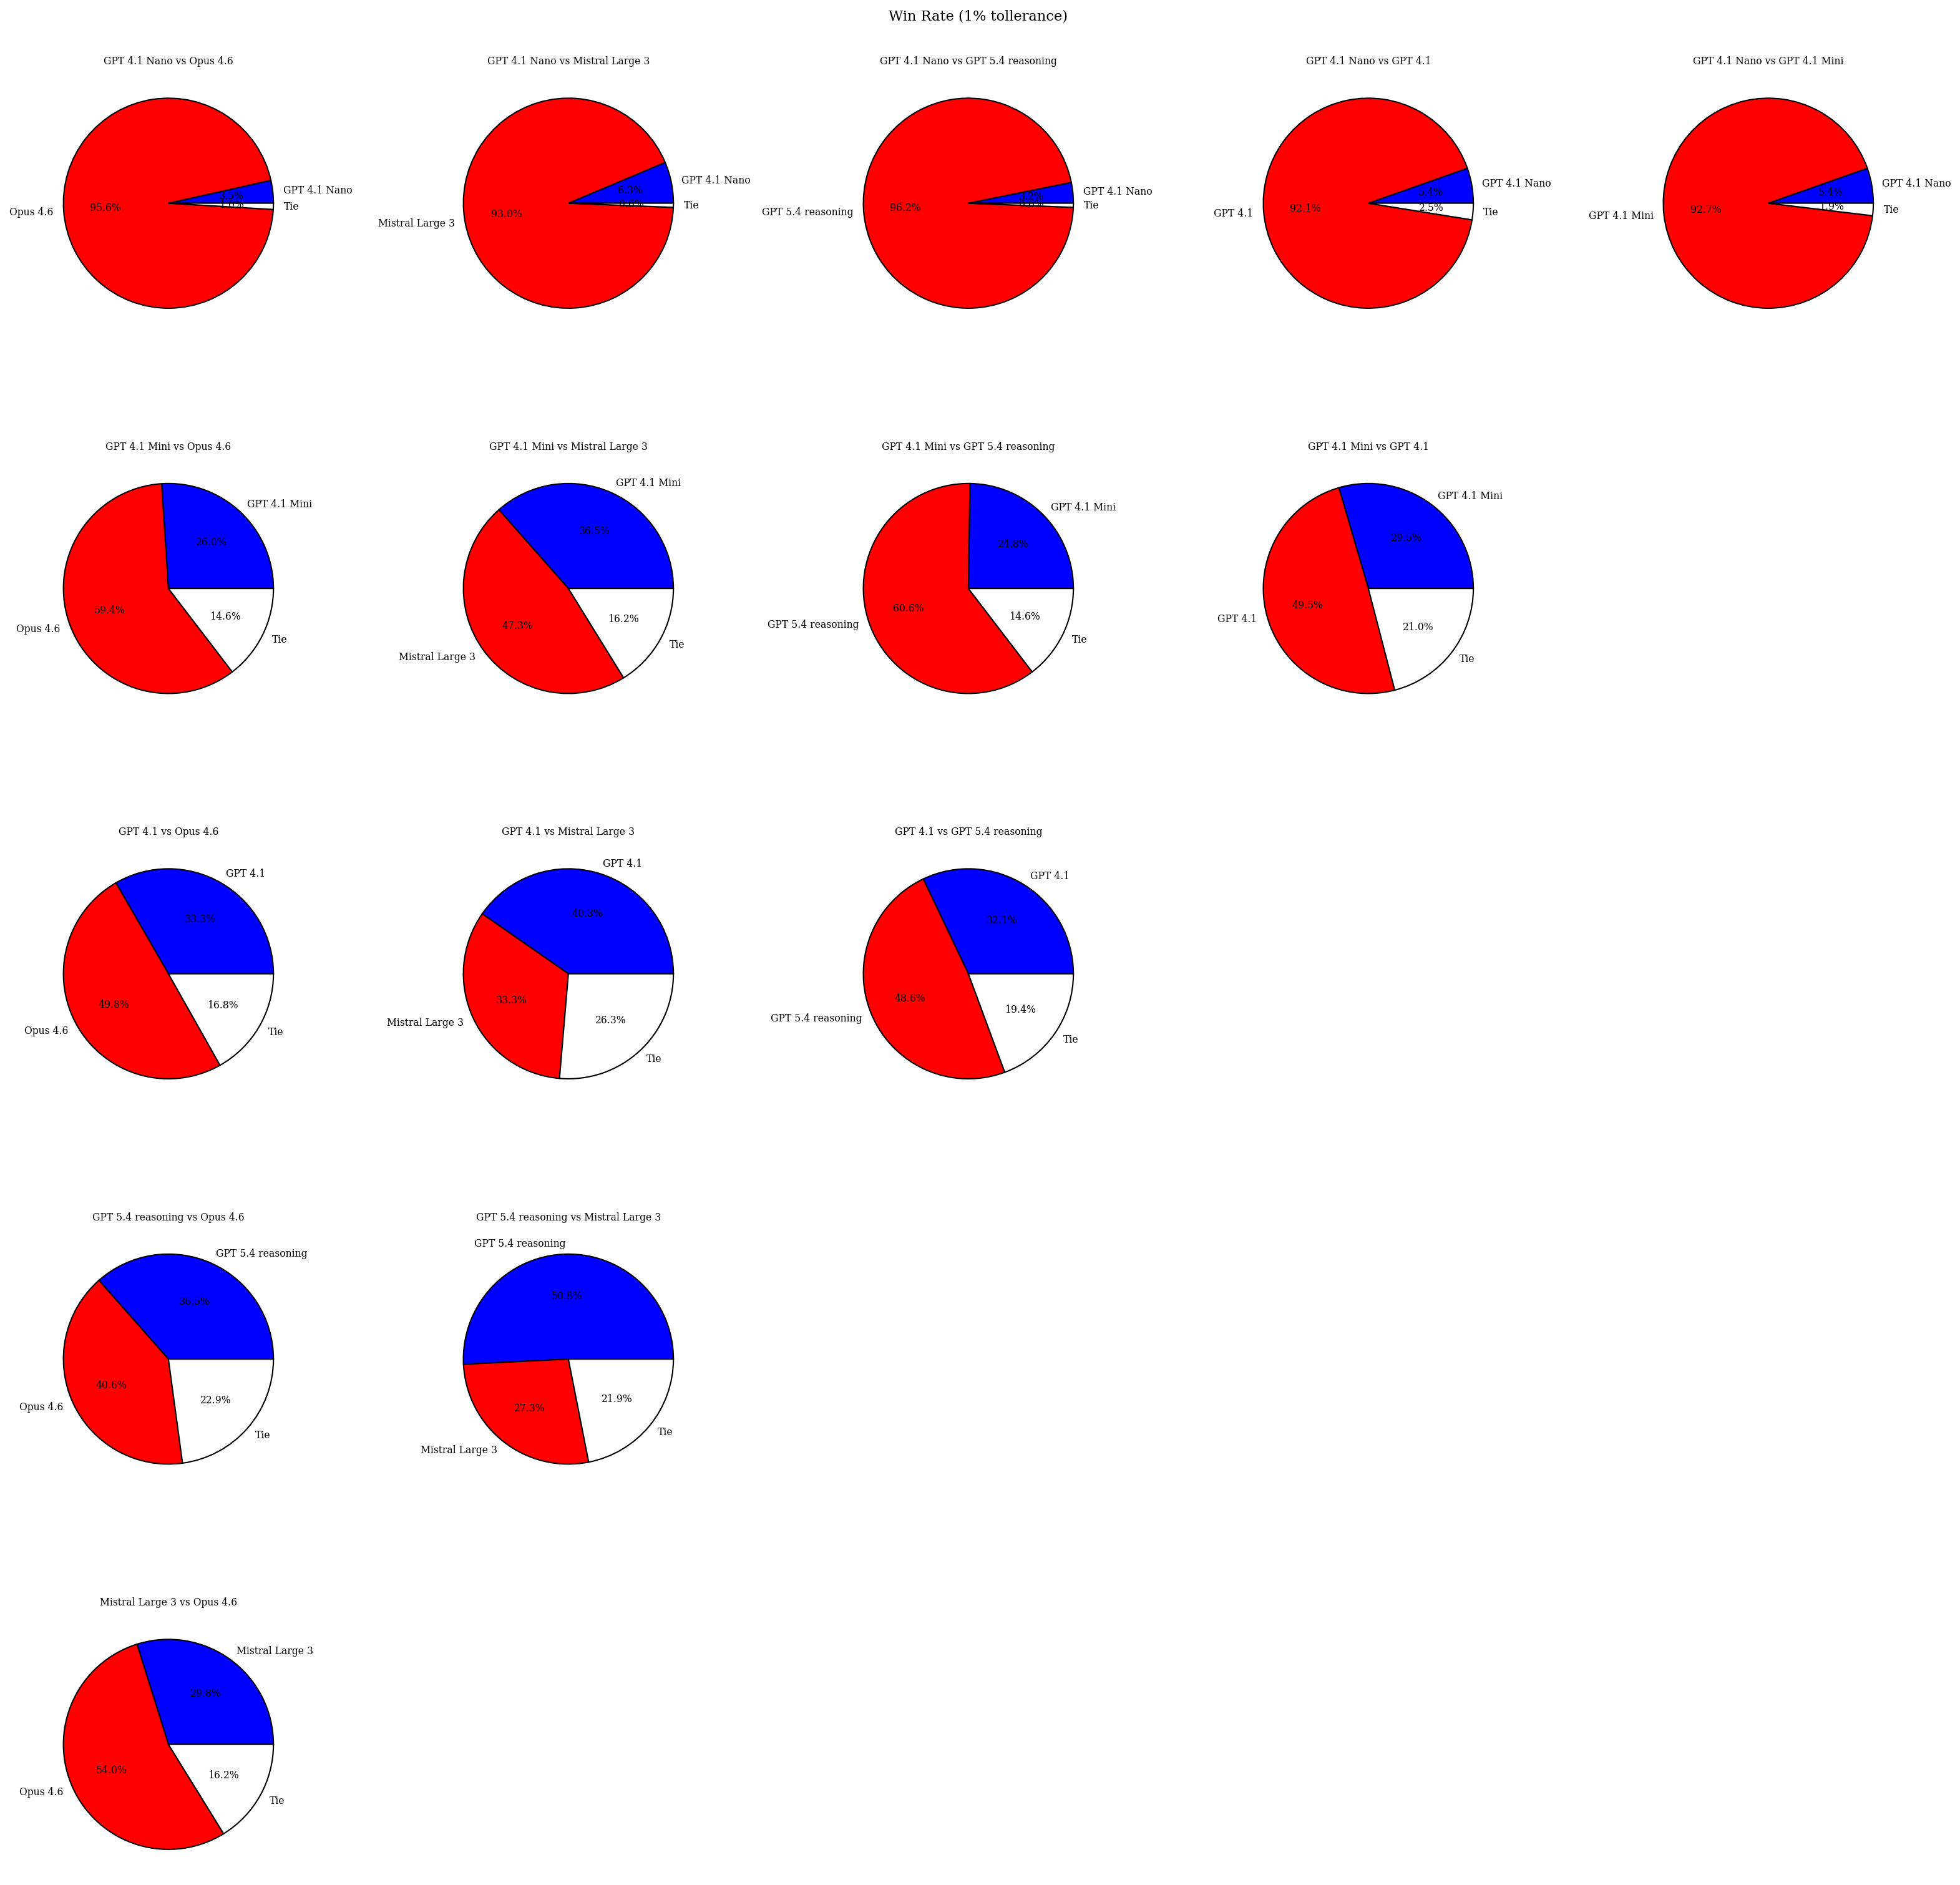

In [89]:
with plt.style.context('tableau-colorblind10'):
    fig, axes = plt.subplots(len(corr), len(corr), figsize=(21, 21))
    tol = 0.01
    fig.suptitle(f'Win Rate ({round(100*tol)}% tollerance) ')
    for c in couples:
        if isinstance(axes, np.ndarray):
            ax = axes[c[0], c[1]]
        else:
            ax = axes
        m1_name = c[2]
        m2_name = c[3]
        m1 = scores[m1_name]
        m2 = scores[m2_name]
        
        counts = {
            f'{m1_name}': (m1 > m2 + tol).sum(),
            f'{m2_name}': (m2 > m1 + tol).sum(),
            f'Tie': ((m1 - m2).abs() <= tol).sum()
        }
            
        ax.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%',
            colors=["#0000ff", '#ff0000', "#ffffff"],
            wedgeprops={'edgecolor': 'black', 'linewidth': 1}, textprops={'fontsize': 'small'})
        ax.set_title(f'{m1_name} vs {m2_name}', fontsize='small')

    if isinstance(axes, np.ndarray):
        for i in range(1, len(axes)):
            for j in range(len(axes)-i, len(axes)):
                axes[i, j].set_visible(False) 
    plt.tight_layout()
    plt.show()

In [90]:
scores.min(axis=None)

np.float64(0.4180790960451978)

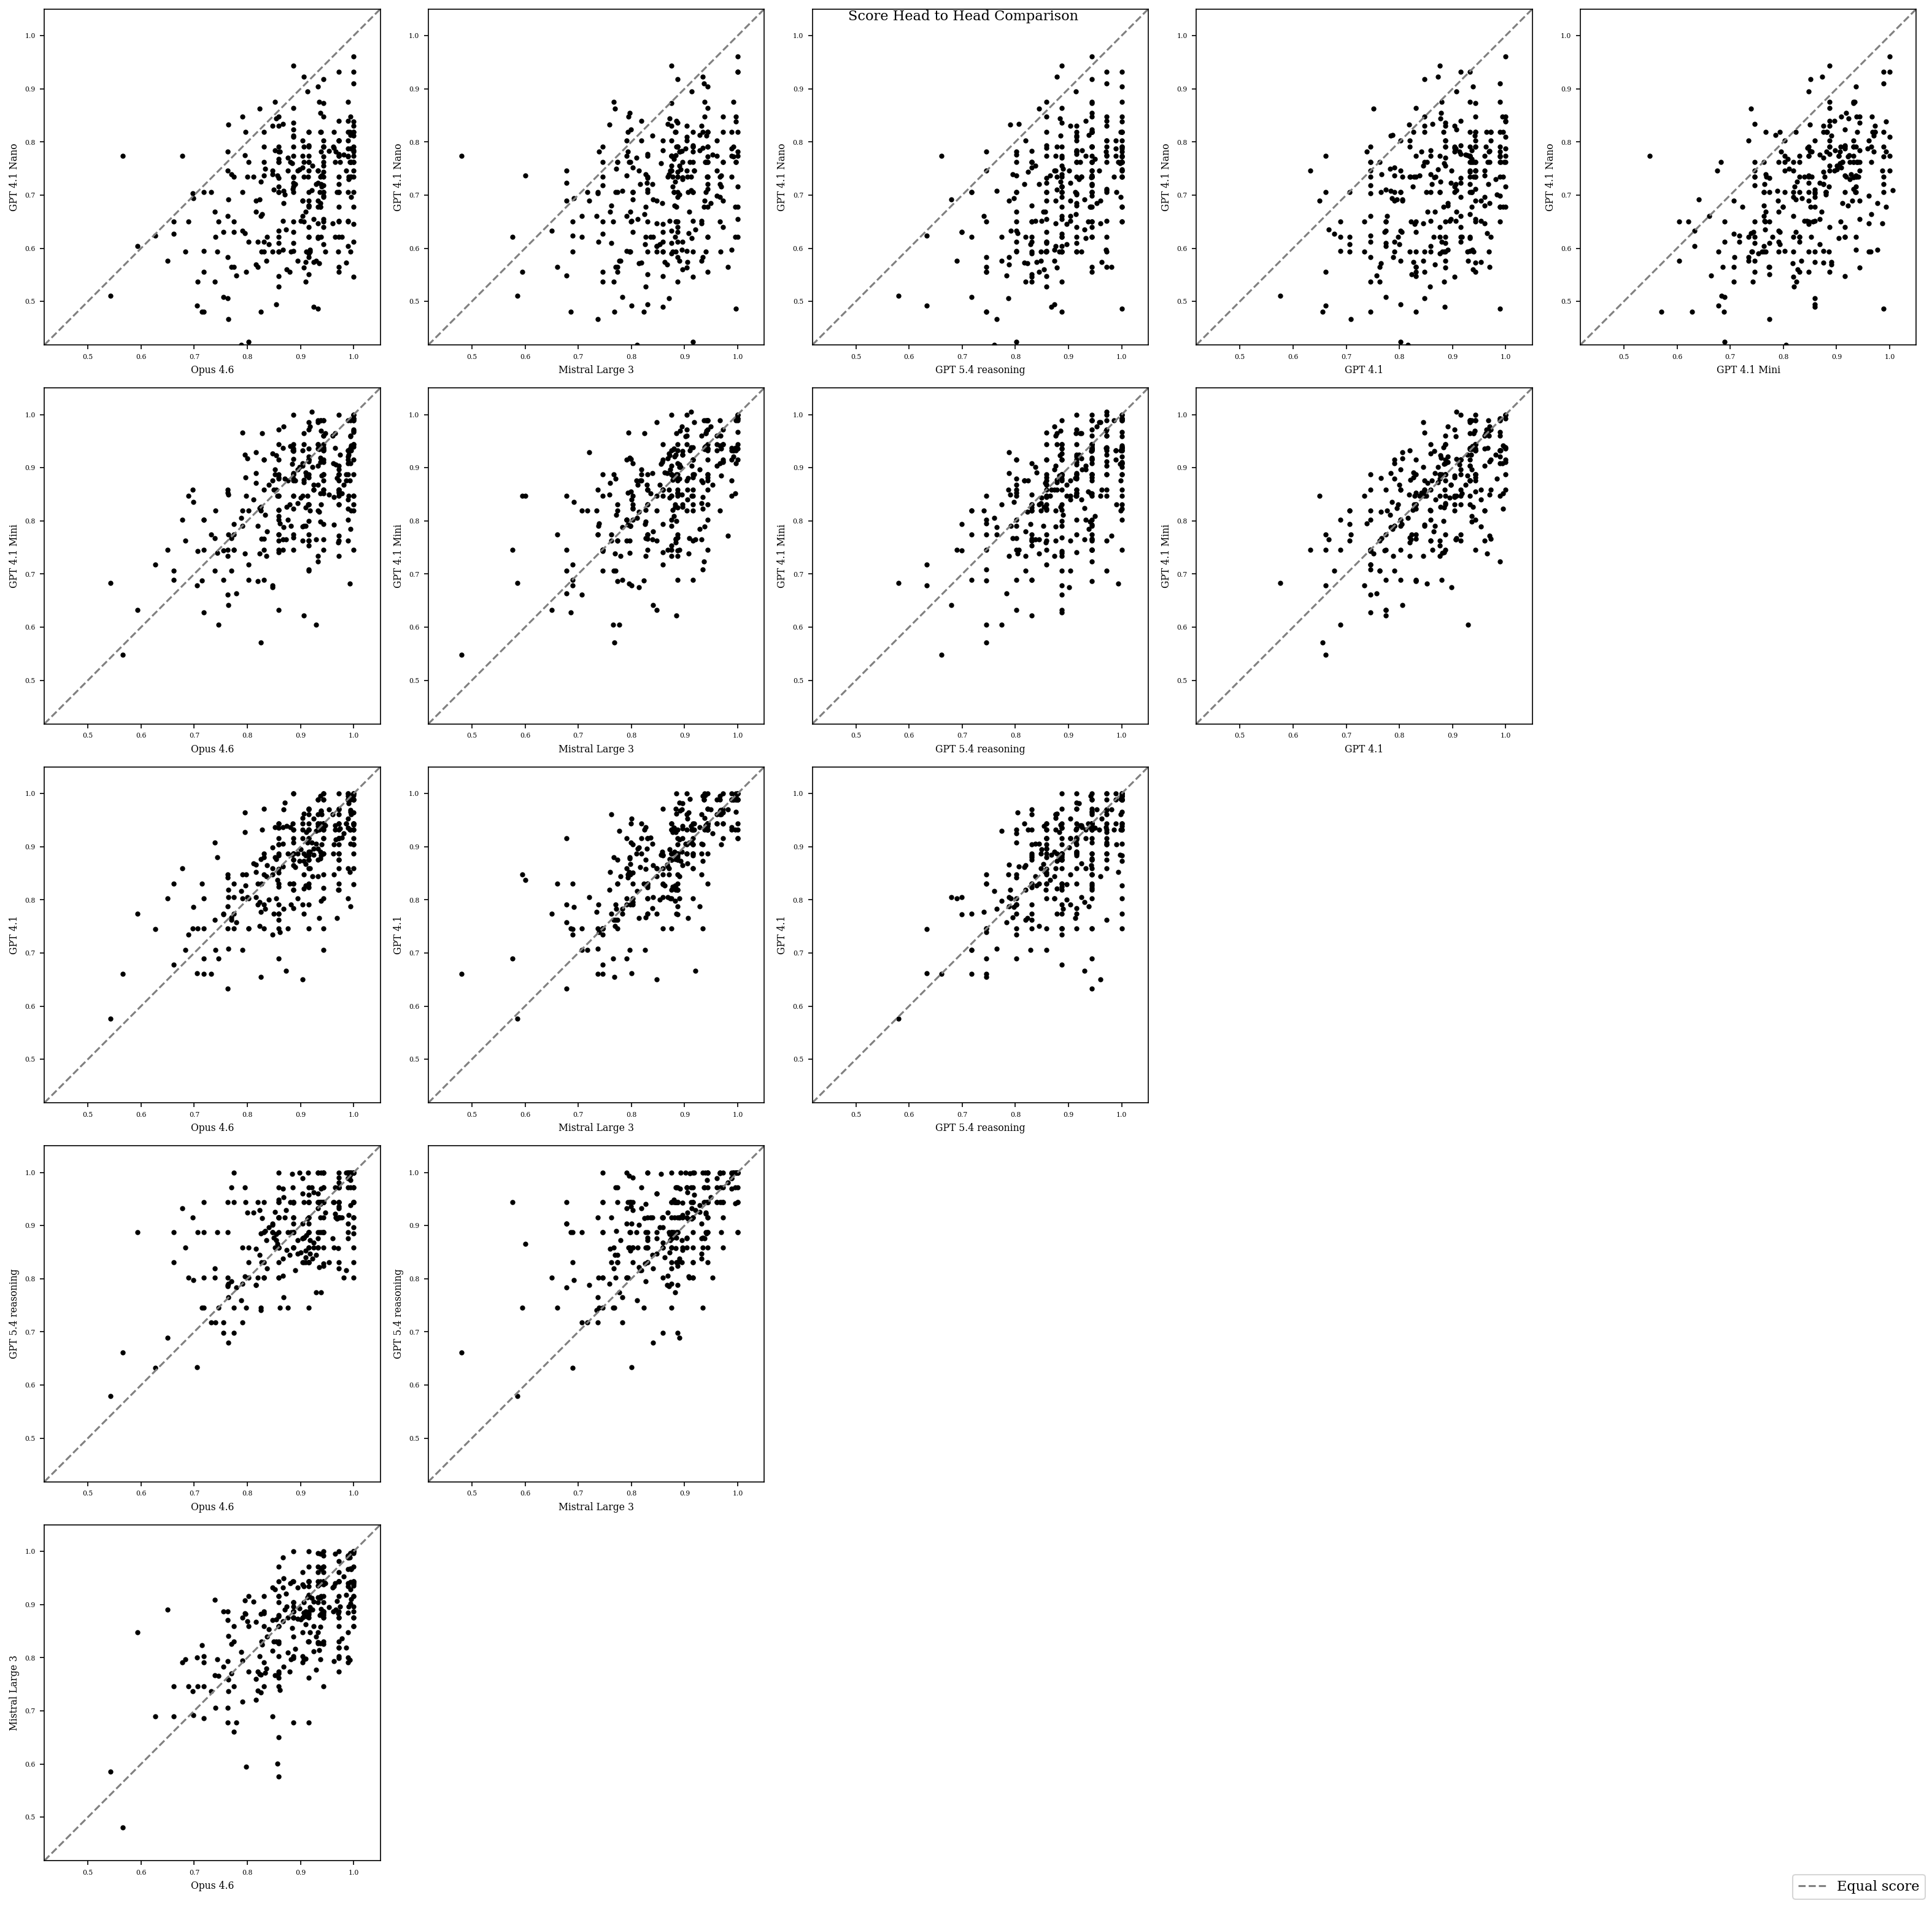

In [91]:
with plt.style.context('tableau-colorblind10'):

    fig, axes = plt.subplots(len(corr), len(corr), figsize=(21, 21))
    lo = scores.min(axis=None)
    for c in couples:
        
        if isinstance(axes, np.ndarray):
            ax = axes[c[0], c[1]]
        else:
            ax = axes
        y = scores[c[2]]
        x = scores[c[3]]

        ax.scatter(x, y, marker='.', color='black')

        # dashed diagonal line
        #lo = min(x.min(), y.min())
        ax.axline((lo, lo), slope=1, ls='--', color='grey', label=f'Equal score')
        #ax.axline((0, 0), slope=1, ls='--', color='grey', label=f'Equal score')
        ax.set_aspect('equal')
        ax.set_box_aspect(1)
        ax.set_ylabel(c[2], fontsize='small')
        ax.set_xlabel(c[3], fontsize='small')
        ax.tick_params(axis='both', labelsize='xx-small')
        ax.set_xlim((lo, 1.05))
        ax.set_ylim((lo, 1.05))
    if isinstance(axes, np.ndarray):
        for ax in axes.flat:
            if not ax.collections:
                ax.set_visible(False)
    #fig.legend()
    # Grab handle/label from any one subplot to avoid duplicates
    handles, labels = axes.flat[0].get_legend_handles_labels() if isinstance(axes, np.ndarray) else axes.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right', fontsize='large')
    fig.suptitle(f'Score Head to Head Comparison')
    plt.tight_layout()
    plt.show()

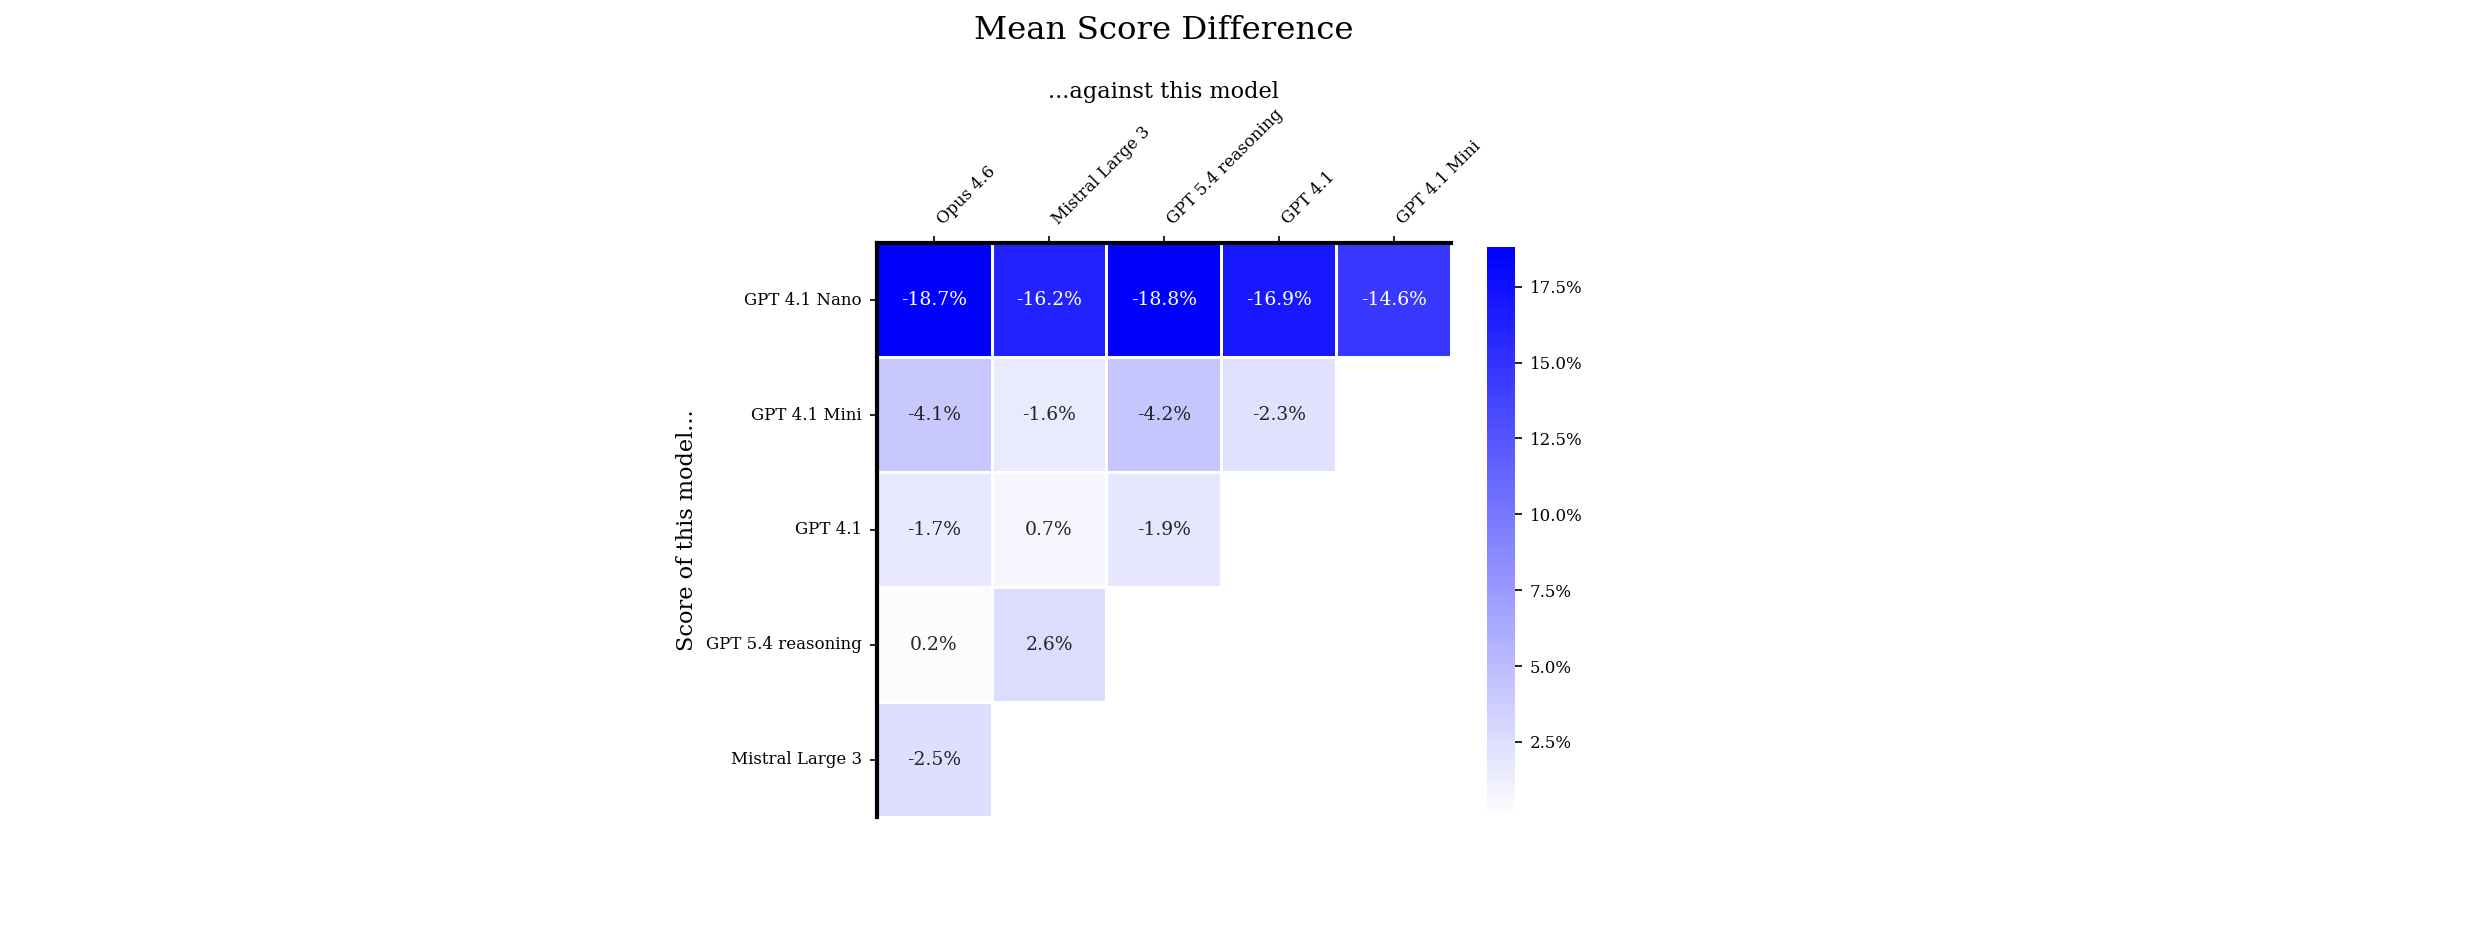

In [92]:
models = scores.columns.tolist()
n = len(models)

diff = pd.DataFrame(index=models, columns=models, dtype=float)

for i in models:
    for j in models:
        diff.loc[i, j] = (scores[i] - scores[j]).mean()


diff = diff[diff.columns[::-1]]
mask = np.tril(np.ones_like(diff, dtype=bool), k=0)
mask = mask[:, ::-1]

diff = diff.iloc[:-1, :-1]
mask = mask[:-1, :-1]


diff_pct = diff * 100

annot_labels = diff_pct.map(lambda x: f"{x:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
ax = axes[1]
# Whiten axes[0] and axes[2]
for i in [0, 2]:
    ax_i = axes[i]
    ax_i.set_facecolor("white")
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    for spine in ax_i.spines.values():
        spine.set_visible(False)

sns.heatmap(diff_pct.abs(), annot=annot_labels, fmt="", cmap=red_white_blue,
                 square=True, linewidths=0.5, mask=mask, ax=ax, center=0, cbar_kws={"shrink": 0.7})

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1f}%")

ax.set_title("Mean Score Difference", pad=20, fontsize='xx-large')
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.set_ylabel('Score of this model...', fontsize='large')
ax.set_xlabel('...against this model', fontsize='large')
ax.set_facecolor("white")

ax.spines['top'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')


#plt.tight_layout()
plt.show()

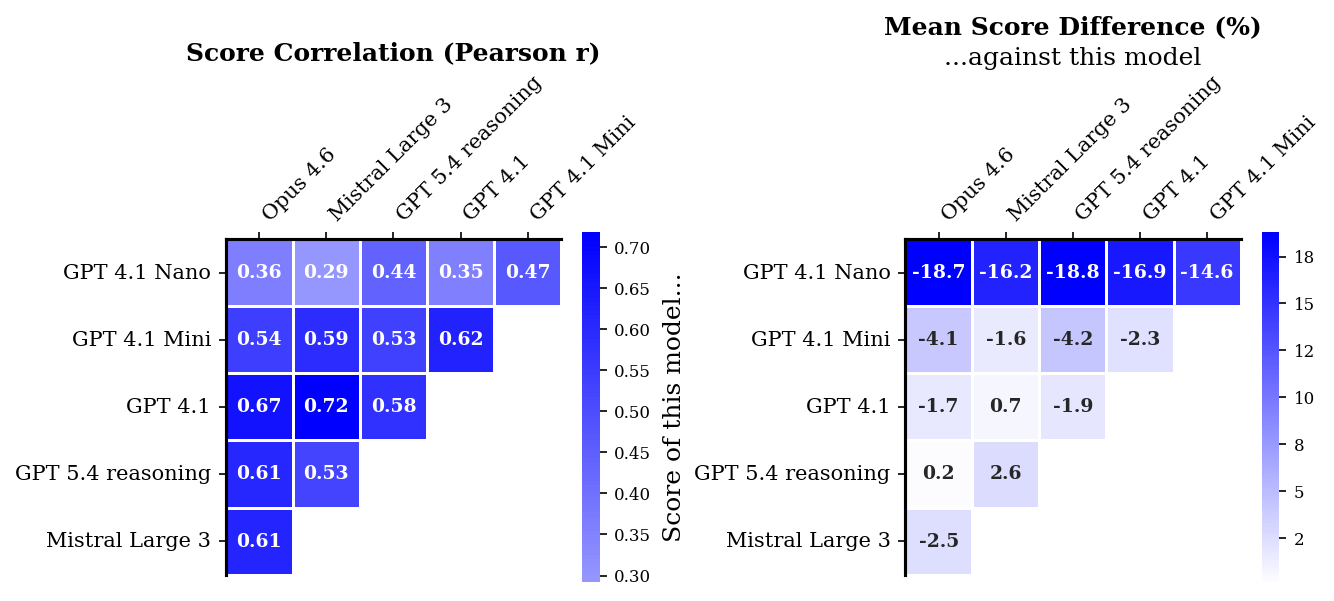

In [116]:
# --- Dati ---
# Correlazione
corr = scores.corr()
corr = corr[corr.columns[::-1]]
mask_corr = np.tril(np.ones_like(corr, dtype=bool), k=0)[:, ::-1]
corr = corr.iloc[:-1, :-1]
mask_corr = mask_corr[:-1, :-1]

# Differenza
models = scores.columns.tolist()
diff = pd.DataFrame(index=models, columns=models, dtype=float)
for i in models:
    for j in models:
        diff.loc[i, j] = (scores[i] - scores[j]).mean()

diff = diff[diff.columns[::-1]]
mask_diff = np.tril(np.ones_like(diff, dtype=bool), k=0)[:, ::-1]
diff = diff.iloc[:-1, :-1]
mask_diff = mask_diff[:-1, :-1]
diff_pct = diff * 100
annot_labels = diff_pct.map(lambda x: f"{x:.1f}")

# --- Figura ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Stile comune
heatmap_kw = dict(square=True, linewidths=0.5, annot_kws={"size": 9, "fontweight": "bold"})
tick_kw = dict(labelsize=8)
spine_kw = dict(color="black", linewidth=1.5)

# --- Correlazione ---
sns.heatmap(
    corr, mask=mask_corr, cmap=red_white_blue, center=0,annot=True, fmt=".2f",
    ax=ax1, cbar_kws={"shrink": 0.6}, **heatmap_kw
)
ax1.set_title("Score Correlation (Pearson r)", fontdict={"fontsize": 12, "fontweight": "bold"})
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="left", fontsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=10)
ax1.set_facecolor("white")
ax1.spines["top"].set(**spine_kw, visible=True)
ax1.spines["left"].set(**spine_kw, visible=True)

# --- Differenza ---
sns.heatmap(
    diff_pct.abs(), mask=mask_diff, annot=annot_labels, fmt="",
    cmap=red_white_blue, center=0, ax=ax2,
    cbar_kws={"shrink": 0.6, "format": lambda x, _: f"{x:.0f}"}, **heatmap_kw
)
ax2.set_title("Mean Score Difference (%)", fontdict={"fontsize": 12, "fontweight": "bold"})
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position("top")
ax2.set_ylabel("Score of this model...", fontsize=12)
ax2.set_xlabel("...against this model", fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="left", fontsize=10)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=10)
ax2.set_facecolor("white")
ax2.spines["top"].set(**spine_kw, visible=True)
ax2.spines["left"].set(**spine_kw, visible=True)

plt.tight_layout()
plt.savefig("model_comparison_heatmaps.pdf", bbox_inches="tight", dpi=300)
plt.show()

C:\Users\lucat\AppData\Local\Temp\ipykernel_23644\753576434.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')


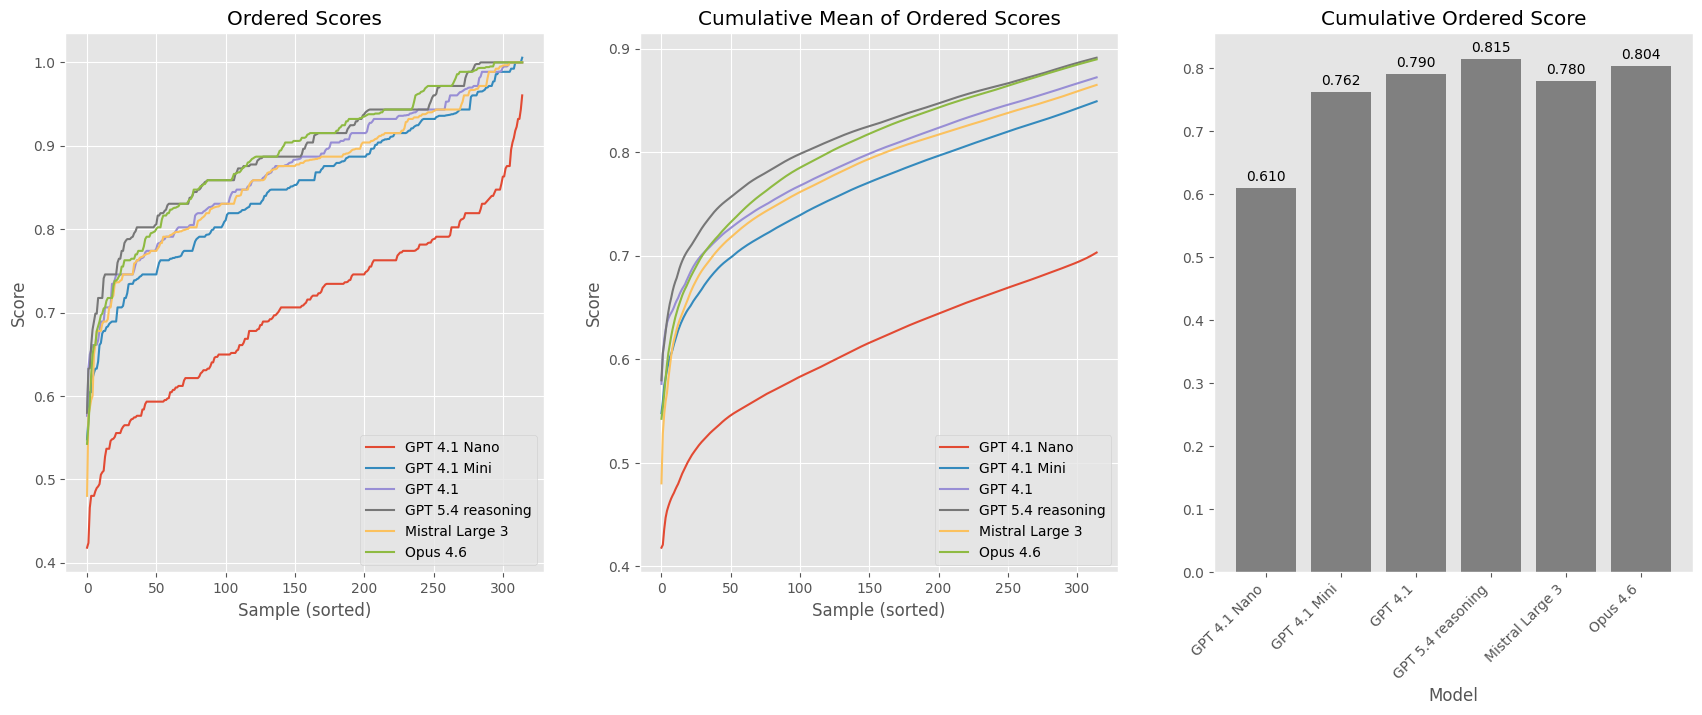

In [55]:
sorted_scores = scores.apply(lambda col: col.sort_values().reset_index(drop=True))
cumulative_mean = sorted_scores.expanding().mean()
cumulative_ordered_score = cumulative_mean.mean()

#with plt.style.context('tableau-colorblind10'):
with plt.style.context('ggplot'):
    x = np.arange(len(sorted_scores))
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 7))
    
    for m in sorted_scores.columns:
        ax1.plot(x, sorted_scores[m], label=m)
        ax2.plot(x, cumulative_mean[m], label=m)
    
    bars = ax3.bar(cumulative_ordered_score.index, cumulative_ordered_score.values, color='grey')
    ax3.bar_label(bars, fmt='%.3f', padding=3)
    
    ax1.legend()
    ax1.set_xlabel('Sample (sorted)')
    ax1.set_ylabel('Score')
    ax1.set_title('Ordered Scores')
    
    ax2.legend()
    ax2.set_xlabel('Sample (sorted)')
    ax2.set_ylabel('Score')
    ax2.set_title('Cumulative Mean of Ordered Scores')
    ax2.legend()
    
    ax3.set_xlabel('Model')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
    ax3.set_title('Cumulative Ordered Score')
    ax3.grid(False)


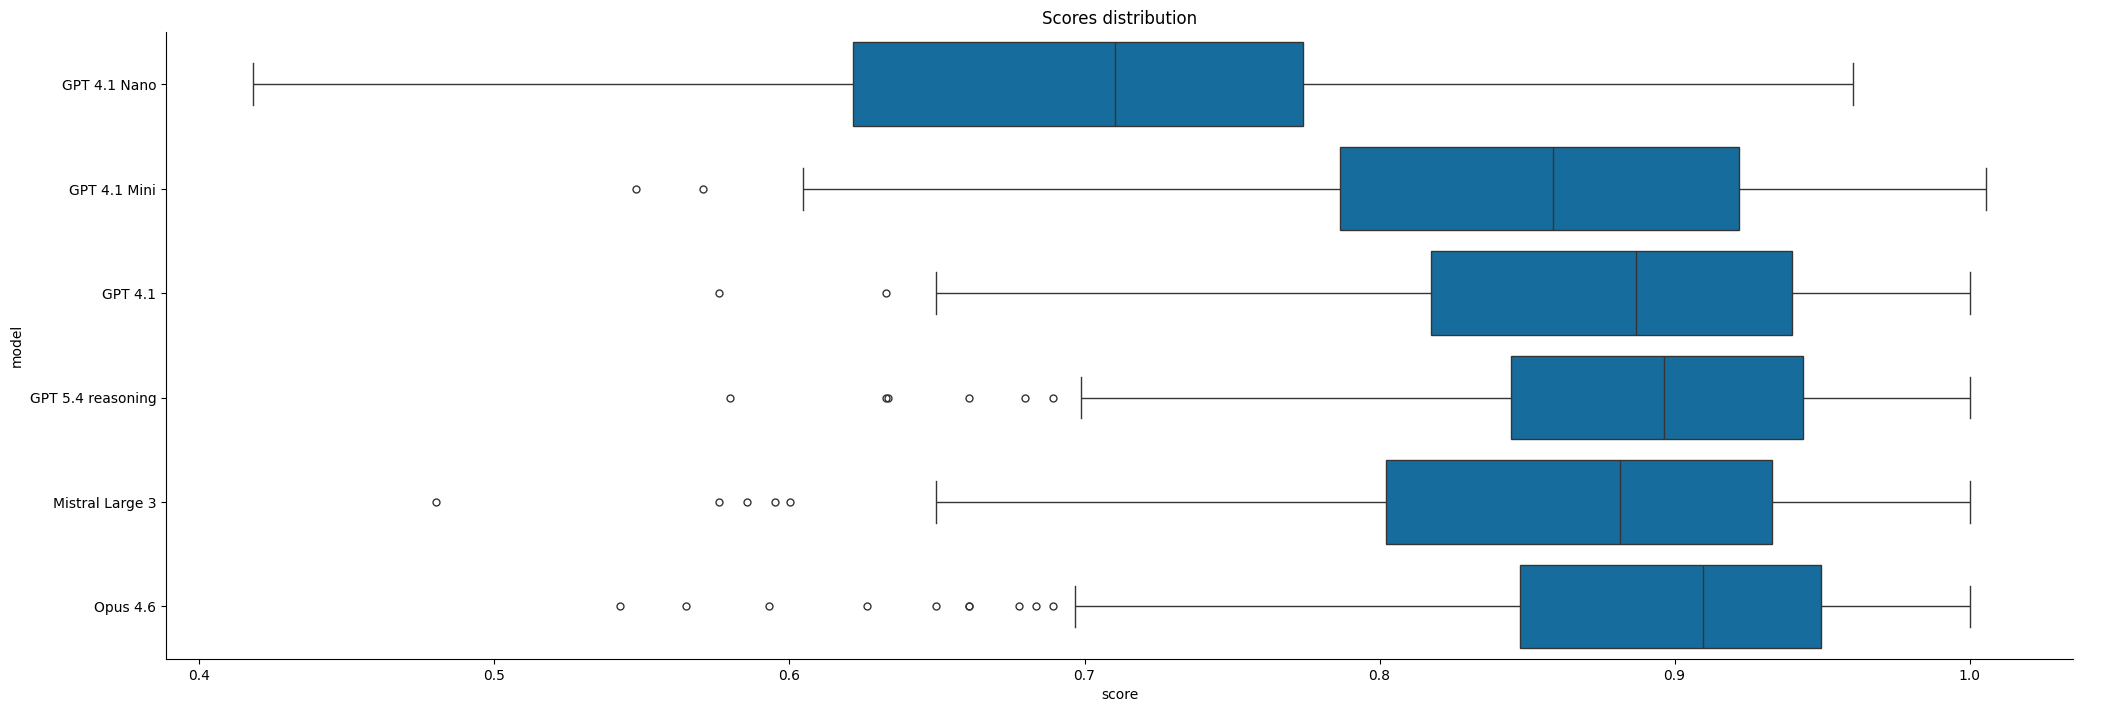

In [56]:
# Normalizziamo COS tra 0 e 1
#norm_scores = (cumulative_ordered_score - cumulative_ordered_score.min()) / (cumulative_ordered_score.max() - cumulative_ordered_score.min())



#print(cumulative_ordered_score)
#palette_sharpe_scores = {model: red_white_blue(norm_scores[model]) for model in cumulative_ordered_score.index}

scores_melted = scores.melt(var_name='model', value_name='score')
sns.catplot(data=scores_melted, y="model", x="score", kind='box', height=7, aspect=21/7)
plt.title("Scores distribution")
plt.show()

In [62]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,          # i caption in LaTeX sono spesso 9-10pt
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 150,       # per la preview; il salvataggio usa il suo
})

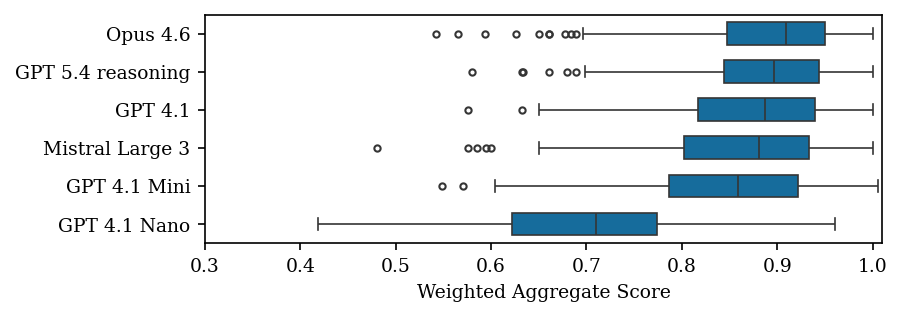

In [65]:
scores_melted = scores.melt(var_name='model', value_name='score')

# Ordina per mediana decrescente
order = scores_melted.groupby('model')['score'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(5.9, 2), constrained_layout=True)

sns.boxplot(
    data=scores_melted,
    y="model",
    x="score",
    order=order,
    ax=ax,
    linewidth=0.8,
    fliersize=3,
    width=0.6,
)

ax.set_xlabel("Weighted Aggregate Score")
ax.set_ylabel(None)
ax.tick_params(labelsize=9)
ax.set_xlim(0.3, 1.01)

#plt.tight_layout()
plt.savefig("boxplot_baseline_scores.pdf", bbox_inches="tight", dpi=150)
plt.show()

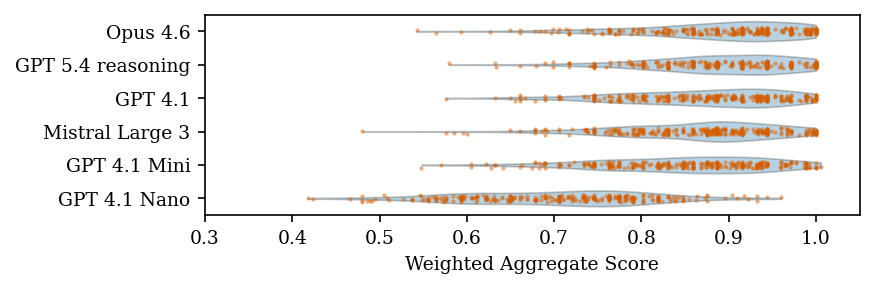

In [72]:
fig, ax = plt.subplots(figsize=(5.9, 2))

sns.violinplot(
    data=scores_melted,
    y="model",
    x="score",
    order=order,
    ax=ax,
    linewidth=0.8,
    width=0.6,
    inner=None,
    cut=0,
    alpha=0.3,
)

sns.stripplot(
    data=scores_melted,
    y="model",
    x="score",
    order=order,
    ax=ax,
    size=2,
    alpha=0.5,
    jitter=0.10,
)

ax.set_xlabel("Weighted Aggregate Score")
ax.set_ylabel(None)
ax.tick_params(labelsize=9)
ax.set_xlim(0.3, 1.05)

plt.tight_layout()
plt.savefig("violinplot_baseline_scores.pdf", bbox_inches="tight", dpi=300)
plt.show()